In [1]:
import numpy as np
import pandas as pd
import os

import random
from PIL import Image, ImageDraw
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torchvision
from torchvision import transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [2]:
from google.colab import drive

drive.mount("/content/drive")

%cd '/content/drive/MyDrive/Project/Colab Notebooks/'

Mounted at /content/drive
/content/drive/MyDrive/Project/Colab Notebooks


In [3]:
# Read in annoted data
train = pd.read_csv('/content/drive/MyDrive/Project/Colab Notebooks/fall.v1-fall2022-03-30.tensorflow/train/_annotations.csv')
train['label'] = train['class'].apply(lambda x: 1 if x == 'fall' else 0)
train.drop(columns=['width', 'height', 'class'], inplace=True)
print(train.head(3))

test=pd.read_csv('/content/drive/MyDrive/Project/Colab Notebooks/fall.v1-fall2022-03-30.tensorflow/test/_annotations.csv')
test['label'] = test['class'].apply(lambda x: 1 if x == 'fall' else 0)
test.drop(columns=['width', 'height', 'class'], inplace=True)
print(test.head(3))

valid=pd.read_csv('/content/drive/MyDrive/Project/Colab Notebooks/fall.v1-fall2022-03-30.tensorflow/valid/_annotations.csv')
valid['label'] = valid['class'].apply(lambda x: 1 if x == 'fall' else 0)
valid.drop(columns=['width', 'height', 'class'], inplace=True)
print(valid.head(3))

print('-------------------------------------')

whole = pd.concat([train, test, valid], ignore_index=True)

#Check numbers of imgs
train_unique_imgs=train.filename.unique()
print('Num of train:',len(train_unique_imgs))
test_unique_imgs=test.filename.unique()
print('Num of test:',len(test_unique_imgs))
valid_unique_imgs=valid.filename.unique()
print('Num of valid:',len(valid_unique_imgs))
print('-------------------------------------')
whole_unique_imgs=whole.filename.unique()
print('Num of whole:',len(whole_unique_imgs))


                                            filename  xmin  ymin  xmax  ymax  \
0  people-8711-_jpg.rf.bff63ec5f1b863d535234d0af2...    22    89   393   325   
1  people-2693-_jpg.rf.c023e0da53c04d5eb3167460f4...   166   140   286   183   
2  people-6785-_jpg.rf.c03fd516fa32a61b28d2c0fb7a...    17   187   223   367   

   label  
0      1  
1      1  
2      1  
                                            filename  xmin  ymin  xmax  ymax  \
0  people-4752-_jpg.rf.010ef79400fc534837828b584d...   174   132   413   407   
1  people-1741-_jpg.rf.011b833c769ee77c3482d96cbe...     0   162   344   391   
2  people-3001-_jpg.rf.014fb6a76ed6e4c3e9bbc69e6e...   159   254   297   380   

   label  
0      1  
1      1  
2      1  
                                            filename  xmin  ymin  xmax  ymax  \
0  people-6358-_jpg.rf.0039d97395c8f6d54527883932...    92   135   329   375   
1  people-3989-_jpg.rf.01779b521396b19e3eebaf3bbd...    60   243   350   415   
2  people-3226-_jpg.rf.0243e25

In [ ]:
# # Load data in instructed format
#     #https://pytorch.org/vision/main/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html#torchvision.models.detection.fasterrcnn_resnet50_fpn

# import torch
# from torch.utils.data import Dataset, DataLoader

# # Define a custom dataset class
# class CustomDataset(Dataset):
#     def __init__(self, dataframe):
#         self.data = []
#         for index, row in dataframe.iterrows():
#             x1, y1, x2, y2 = row['xmin'], row['ymin'], row['xmax'], row['ymax'] # Extract bounding box coordinates and class label
#             label = row['label']
#             self.data.append({'boxes': torch.tensor([x1, y1, x2, y2], dtype=torch.float32),
#                               'labels': torch.tensor(label, dtype=torch.int64)}) # Append to the list as a dictionary

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         return self.data[idx]

# # Instantiate custom dataset and create DataLoader for the dataset
# train_dataset = CustomDataset(train)
# train_dl = DataLoader(train_dataset, batch_size=16, shuffle=True, pin_memory=True if torch.cuda.is_available() else False)

# test_dataset = CustomDataset(test)
# test_dl = DataLoader(test_dataset, batch_size=8, shuffle=True, pin_memory=True if torch.cuda.is_available() else False)

# print(type(test_dataset),len(test_dataset))

# for data in test_dl:
#         print(data)

In [4]:
class CustDat(torch.utils.data.Dataset):
    def __init__(self, df, unique_imgs, indices):
        self.df=df
        self.unique_imgs=unique_imgs
        self.indices=indices
    def __len__(self):
        return len(self.indices)
    def __getitem__(self,idx):
        image_name=self.unique_imgs[self.indices[idx]]
        boxes=self.df[self.df.filename==image_name].values[:,1:5].astype('float32')
        img=Image.open('/content/drive/MyDrive/Project/Colab Notebooks/fall.v1-fall2022-03-30.tensorflow/Whole/'+image_name).convert('RGB')
        labels=self.df[self.df.filename==image_name].values[:,-1].astype('int64')
        target={}
        target['boxes']=torch.tensor(boxes)
        target['label']=torch.tensor(labels)
        return T.ToTensor()(img),target

def custom_collate(data):
    return data

In [5]:
#Split data into train and test
unique_imgs=whole.filename.unique()
train_inds,test_inds=train_test_split(range(unique_imgs.shape[0]),test_size=0.2,random_state=42)

print(len(train_inds),len(test_inds))

#Load data
train_dl=torch.utils.data.DataLoader(CustDat(whole,unique_imgs,train_inds),batch_size=16,shuffle=True,collate_fn=custom_collate,
                                     pin_memory=True if torch.cuda.is_available() else False)

test_dl=torch.utils.data.DataLoader(CustDat(whole,unique_imgs,test_inds),batch_size=8,shuffle=True,collate_fn=custom_collate,
                                     pin_memory=True if torch.cuda.is_available() else False)

# for data in test_dl:
#     print(data)

3585 897


In [6]:
#Load model and define essential hyperparameters

model=torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=True)
num_classes=2
in_features=model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor=FastRCNNPredictor(in_features,num_classes)

device=torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

optimizer=torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9,weight_decay=0.0005)
num_epoch=25

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 155MB/s]


cuda


46.53880441188812
31.441621996462345
27.84000424295664
25.666368313133717
23.808748323470354
22.431602485477924
21.22446282953024
20.14264217019081
19.089107304811478
18.141664914786816
17.254807382822037
16.37170392088592
15.711347974836826
15.121870841830969
14.357669966295362


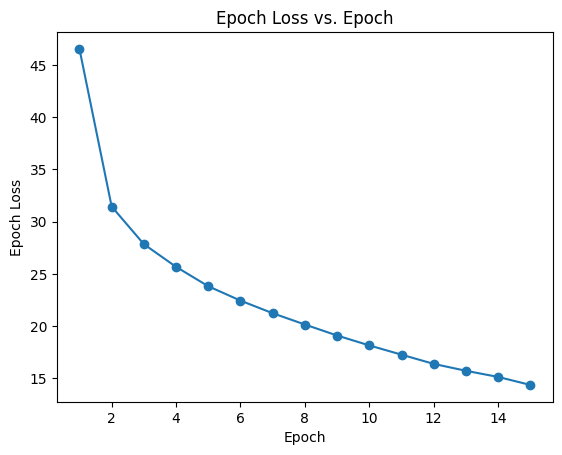

In [7]:
# #training
# model.to(device)
# epoch_losses=[]

# for epochs in range(num_epoch):
#     epoch_loss=0
#     for i,data in enumerate(train_dl):
#       imgs=[]
#       labels=[]
#       for d in data:
#         imgs.append(d[0].to(device))
#         label={}
#         label['boxes']=d[1]['boxes'].to(device)
#         label['labels']=d[1]['label'].to(device)
#         labels.append(label)

#       loss_dict=model(imgs,labels)
#       loss=sum(v for v in loss_dict.values())
#       epoch_loss+=loss.cpu().detach().numpy()
#       optimizer.zero_grad()
#       loss.backward()
#       optimizer.step()

#     epoch_losses.append(epoch_loss)
#     print(epoch_loss)


# # Plot epoch loss
# plt.plot(range(1, num_epoch + 1), epoch_losses, marker='o')
# plt.xlabel('Epoch')
# plt.ylabel('Epoch Loss')
# plt.title('Epoch Loss vs. Epoch')
# plt.grid(False)
# plt.show()

In [ ]:
model.to(device)
train_losses = []
test_losses = []

for epoch in range(num_epoch):
    train_loss = 0
    for i, train_data in enumerate(train_dl):
        train_imgs = []
        train_labels = []
        for d in train_data:
            train_imgs.append(d[0].to(device))
            label = {'boxes': d[1]['boxes'].to(device), 'labels': d[1]['label'].to(device)}
            train_labels.append(label)

        loss_dict = model(train_imgs, train_labels)
        loss = sum(v for v in loss_dict.values())
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_losses.append(train_loss / len(train_dl))

    # Evaluate on test data
    test_loss = 0
    with torch.no_grad():
        for test_data in test_dl:
            test_imgs = []
            test_labels = []
            for d in test_data:
                test_imgs.append(d[0].to(device))
                label = {'boxes': d[1]['boxes'].to(device), 'labels': d[1]['label'].to(device)}
                test_labels.append(label)

            test_loss_dict = model(test_imgs, test_labels)
            test_loss += sum(v for v in test_loss_dict.values()).item()

    test_losses.append(test_loss / len(test_dl))

    print(f"Epoch [{epoch+1}/{num_epoch}], Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}")

# Plot both training and test losses
plt.plot(range(1, num_epoch + 1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, num_epoch + 1), test_losses, marker='o', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()
plt.grid(False)
plt.show()

In [ ]:
# Run inference on one test sample
model.eval()
data=iter(test_dl).__next__()

img=data[0][0]
boxes=data[0][1]['boxes']
labels=data[0][1]['label']

output=model([img.to(device)])

print(output)

#display inference
output_box=output[0]['boxes']
output_scores=output[0]['scores']
keep=torchvision.ops.nms(output_box,output_scores,0.9)

im=(img.permute(1,2,0).cpu().detach().numpy()*255).astype('unit8')
vsample=Image.fromarray(im)

draw=ImageDraw(vsample)
for box in boxes:
  draw.rectangle(list(box),fill=None,outline='red')
vsample


In [ ]:
from sklearn.metrics import precision_score, recall_score

# Function to calculate IoU between two bounding boxes
def calculate_iou(box1, box2):
    # Calculate intersection coordinates
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Calculate intersection area
    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)

    # Calculate areas of each box
    box1_area = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
    box2_area = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)

    # Calculate union area
    union_area = box1_area + box2_area - intersection_area

    # Calculate IoU
    iou = intersection_area / union_area
    return iou

# Run inference on one test sample
model.eval()
data = iter(test_dl).__next__()

img = data[0][0]
boxes = data[0][1]['boxes']
labels = data[0][1]['labels']

output = model([img.to(device)])

output_boxes = output[0]['boxes']
output_scores = output[0]['scores']

# Filter boxes based on confidence score using NMS
keep = torchvision.ops.nms(output_boxes, output_scores, 0.9)
filtered_output_boxes = output_boxes[keep].cpu().detach().numpy()

# Calculate metrics
ground_truth_boxes = [box.cpu().detach().numpy() for box in boxes]
accuracy, precision, recall = calculate_iou(ground_truth_boxes, filtered_output_boxes)

# Display inference
im = (img.permute(1, 2, 0).cpu().detach().numpy() * 255).astype('uint8')
vsample = Image.fromarray(im)

draw = ImageDraw(vsample)
for box in ground_truth_boxes:
    draw.rectangle(list(box), fill=None, outline='red')

vsample.show()

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)